In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pickle

print("All libraries ready!")


All libraries ready!


In [40]:
df=pd.read_csv(r"C:\Users\Aarti\Documents\Internship\creditcard_2023.csv (1)\creditcard_2023.csv")
df.head()
df.drop(columns=['id'], inplace=True)

print("Shape after dropping id:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape after dropping id: (568630, 30)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 3 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0


In [41]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total rows:    {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
print("\nData types:")
print(df.dtypes.value_counts())

DATASET OVERVIEW
Total rows:    568,630
Total columns: 30

Missing values:
Series([], dtype: int64)

Data types:
float64    29
int64       1
Name: count, dtype: int64


CLASS DISTRIBUTION
Legitimate  :  284,315  (50.000%)
Fraud       :  284,315  (50.000%)


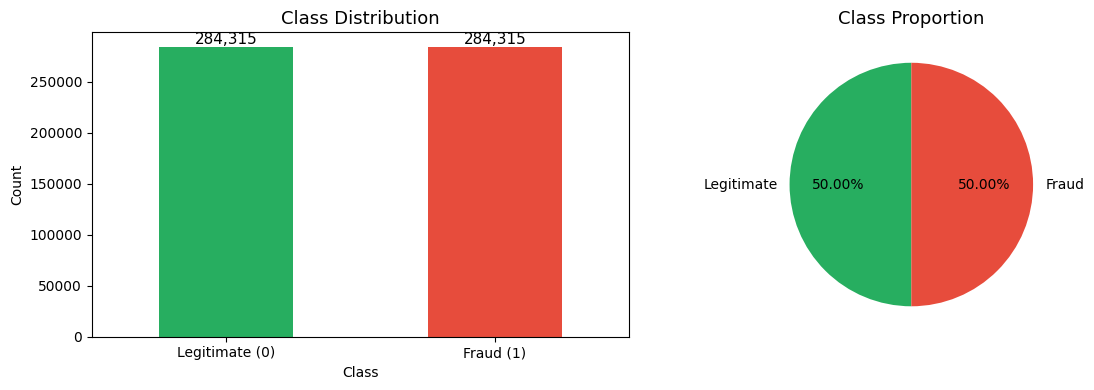

In [42]:
print("="*50)
print("CLASS DISTRIBUTION")
print("="*50)

counts  = df['Class'].value_counts()
percent = df['Class'].value_counts(normalize=True) * 100

for cls, label in [(0,'Legitimate'), (1,'Fraud')]:
    if cls in counts:
        print(f"{label:12}: {counts[cls]:>8,}  ({percent[cls]:.3f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = {0: '#27ae60', 1: '#e74c3c'}
df['Class'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=[colors[i] for i in df['Class'].value_counts().index]
)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
 ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(counts, labels=['Legitimate', 'Fraud'],
            colors=['#27ae60','#e74c3c'],
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.show()

AMOUNT ANALYSIS
          count          mean          std    min      25%       50%  \
Class                                                                  
0      284315.0  12026.313506  6929.500715  50.12  6034.54  11996.90   
1      284315.0  12057.601763  6909.750891  50.01  6074.64  12062.45   

             75%       max  
Class                       
0      18040.265  24039.93  
1      18033.780  24039.93  


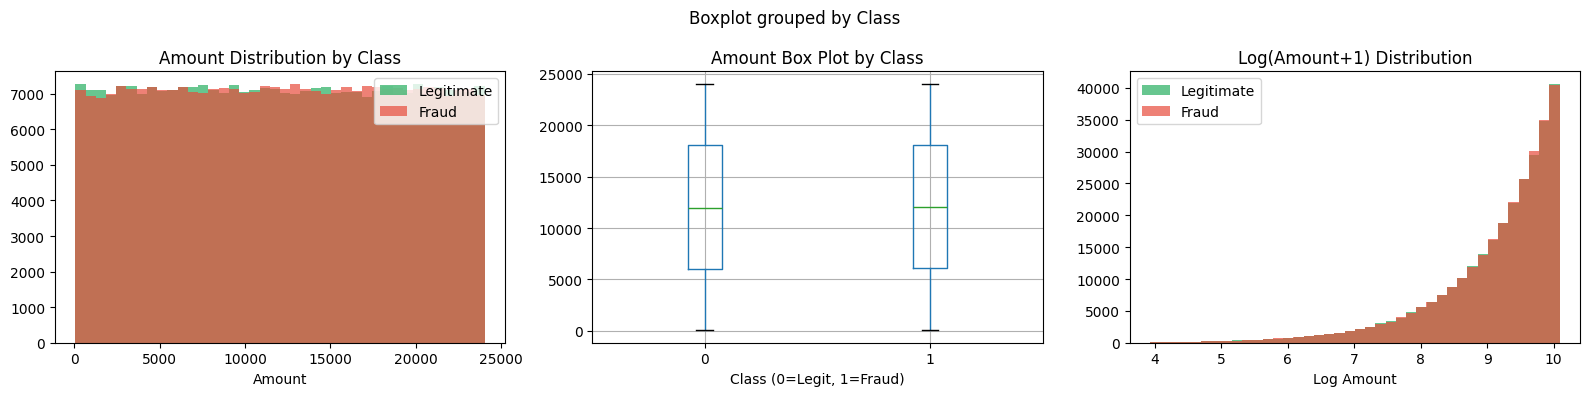

In [43]:
print("="*50)
print("AMOUNT ANALYSIS")
print("="*50)
print(df.groupby('Class')['Amount'].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution by class
for cls, label, color in [(0,'Legitimate','#27ae60'), (1,'Fraud','#e74c3c')]:
    data = df[df['Class']==cls]['Amount']
    if len(data) > 0:
        axes[0].hist(data, bins=40, alpha=0.7, color=color, label=label)
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlabel('Amount')
axes[0].legend()

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount Box Plot by Class')
axes[1].set_xlabel('Class (0=Legit, 1=Fraud)')

# Log scale amount
for cls, label, color in [(0,'Legitimate','#27ae60'), (1,'Fraud','#e74c3c')]:
    data = df[df['Class']==cls]['Amount']
    if len(data) > 0:
        axes[2].hist(np.log1p(data), bins=40, alpha=0.7, color=color, label=label)
axes[2].set_title('Log(Amount+1) Distribution')
axes[2].set_xlabel('Log Amount')
axes[2].legend()

plt.tight_layout()
plt.show()

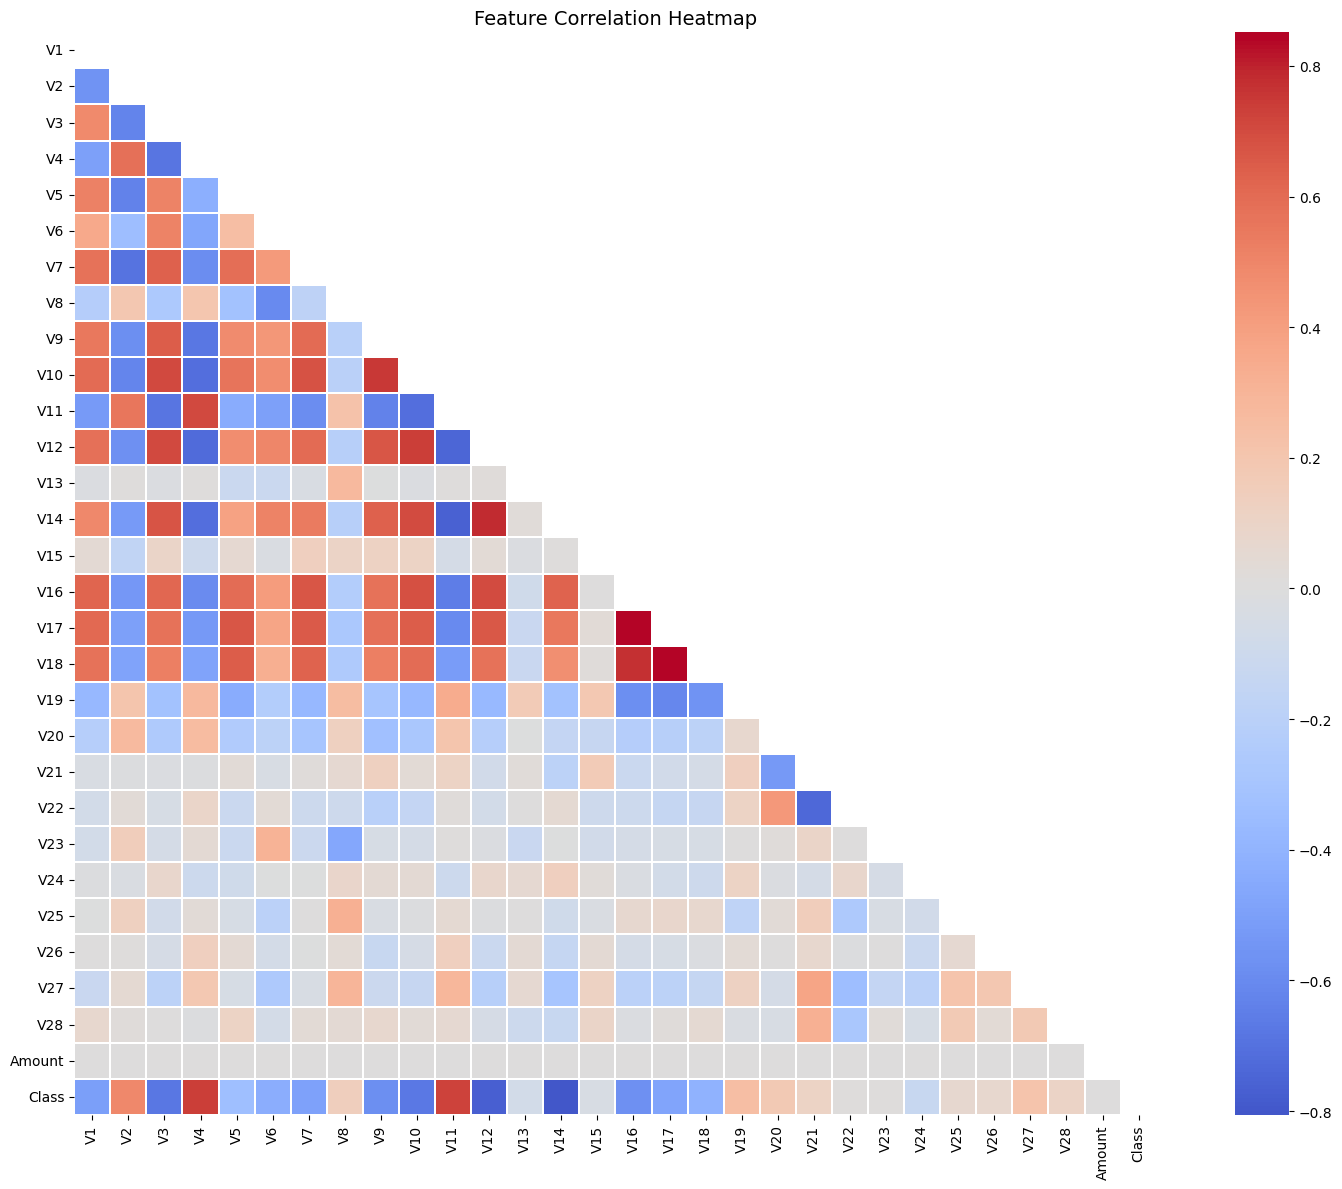


Top 10 features most correlated with fraud:
V14    0.805669
V12    0.768579
V4     0.735981
V11    0.724278
V3     0.682095
V10    0.673665
V9     0.585522
V16    0.573511
V1     0.505761
V2     0.491878
Name: Class, dtype: float64


In [44]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Only lower triangle
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3,
            annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top features correlated with Class
print("\nTop 10 features most correlated with fraud:")
print(corr['Class'].abs().sort_values(ascending=False).iloc[1:11])

In [45]:
print("Statistical Summary:")
df.describe().T.style.background_gradient(cmap='Blues')

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
V1,568630.000000,-0.000000,1.000001,-3.495584,-0.565286,-0.093638,0.832658,2.229046
V2,568630.000000,-0.000000,1.000001,-49.966572,-0.486678,-0.135894,0.343555,4.361865
V3,568630.000000,0.000000,1.000001,-3.183760,-0.649299,0.000353,0.628538,14.125834
V4,568630.000000,0.000000,1.000001,-4.951222,-0.656020,-0.073762,0.707005,3.201536
V5,568630.000000,0.000000,1.000001,-9.952786,-0.293496,0.081088,0.439737,42.716891
V6,568630.000000,0.000000,1.000001,-21.111108,-0.445871,0.078718,0.497788,26.168402
V7,568630.000000,0.000000,1.000001,-4.351839,-0.283533,0.233366,0.525955,217.873038
V8,568630.000000,0.000000,1.000001,-10.756342,-0.192257,-0.114524,0.047299,5.958040
V9,568630.000000,0.000000,1.000001,-3.751919,-0.568745,0.092526,0.559262,20.270062
V10,568630.000000,0.000000,1.000001,-3.163276,-0.590101,0.262614,0.592460,31.722709


In [46]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Drop original Amount (replaced by scaled version)
df.drop(columns=['Amount'], inplace=True)

print("Amount scaled. New shape:", df.shape)
print("New columns:", df.columns.tolist())

Amount scaled. New shape: (568630, 30)
New columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled']


In [47]:
# ── Step 2: Separate features and target ─────────────────
X = df.drop('Class', axis=1)
y = df['Class']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass breakdown in y:")
print(y.value_counts())

X shape: (568630, 29)
y shape: (568630,)

Class breakdown in y:
Class
0    284315
1    284315
Name: count, dtype: int64


In [48]:
# ── Step 3: Train-Test Split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           # Keeps class ratio same in train and test
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Testing set:  {X_test.shape[0]:,} rows")
print(f"\nFraud in train: {y_train.sum():,}")
print(f"Fraud in test:  {y_test.sum():,}")

Training set: 454,904 rows
Testing set:  113,726 rows

Fraud in train: 227,452
Fraud in test:  56,863


Before Resampling:
Legitimate: 227,452
Fraud: 227,452

Using SMOTE...

After Resampling:
Legitimate: 227,452
Fraud: 227,452


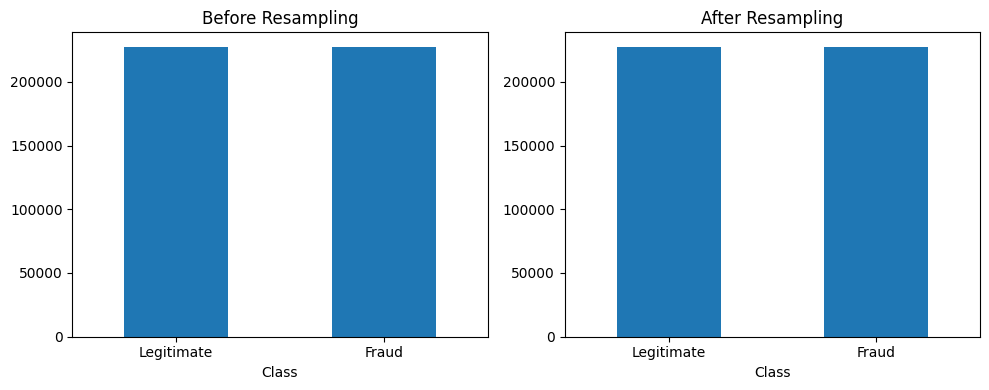

In [50]:
# ── Step 4: Handle Class Imbalance with SMOTE ─────────────
# ONLY apply to training data — NEVER to test data

from imblearn.over_sampling import SMOTE, RandomOverSampler

print("Before Resampling:")
print(f"Legitimate: {(y_train==0).sum():,}")
print(f"Fraud: {(y_train==1).sum():,}")

# Count fraud samples
fraud_count = (y_train == 1).sum()

# 🔥 IMPORTANT
# If fraud samples are too low, use RandomOverSampler
if fraud_count < 6:

    print("\nToo few fraud samples for SMOTE.")
    print("Using RandomOverSampler instead...")

    ros = RandomOverSampler(random_state=42)
    X_train_sm, y_train_sm = ros.fit_resample(X_train, y_train)

else:

    print("\nUsing SMOTE...")

    smote = SMOTE(
        random_state=42,
        sampling_strategy='auto',   # safest option
        k_neighbors=min(3, fraud_count - 1)
    )

    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter Resampling:")
print(f"Legitimate: {(y_train_sm==0).sum():,}")
print(f"Fraud: {(y_train_sm==1).sum():,}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y_train).value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Before Resampling'
)

pd.Series(y_train_sm).value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='After Resampling'
)

for ax in axes:
    ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

In [51]:
# ── Evaluation helper function ────────────────────────────
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred       = (y_pred_proba >= threshold).astype(int)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud'],
          zero_division=0))

    roc_auc = roc_auc_score(y_test, y_pred_proba) if len(y_test.unique()) > 1 else 0
    ap      = average_precision_score(y_test, y_pred_proba) if y_test.sum() > 0 else 0

    print(f"ROC-AUC:           {roc_auc:.4f}")
    print(f"Avg Precision(AP): {ap:.4f}")

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'],
                linewidths=1)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {
        'Model':         model_name,
        'ROC-AUC':       round(roc_auc, 4),
        'Avg Precision': round(ap, 4),
        'F1 (Fraud)':    round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Precision':     round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':        round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

Training Logistic Regression...

  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.95      0.98      0.96     56863
       Fraud       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726

ROC-AUC:           0.9934
Avg Precision(AP): 0.9944


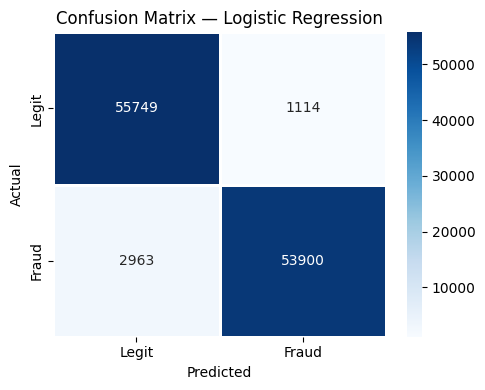

In [52]:
# ── Model 1: Logistic Regression ─────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',   # Extra imbalance handling
    C=0.01                     # Regularization
)
lr.fit(X_train_sm, y_train_sm)
lr_results = evaluate_model(lr, X_test, y_test, "Logistic Regression")

Training Random Forest...

  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99     56863
       Fraud       1.00      0.97      0.99     56863

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726

ROC-AUC:           0.9995
Avg Precision(AP): 0.9995


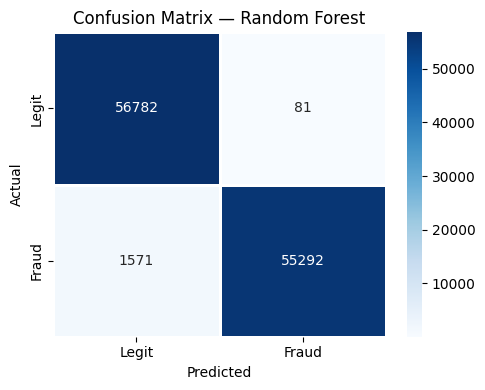

In [53]:
# ── Model 2: Random Forest ────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
rf_results = evaluate_model(rf, X_test, y_test, "Random Forest")

Training XGBoost...
scale_pos_weight: 1.0

  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC:           1.0000
Avg Precision(AP): 1.0000


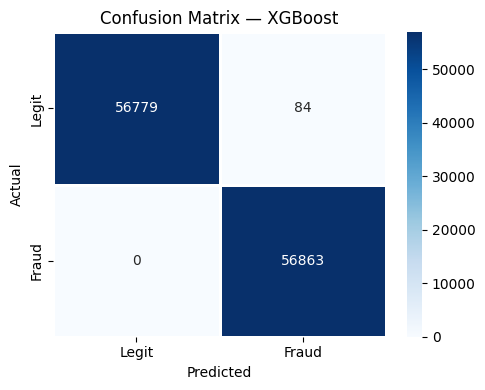

In [54]:
# ── Model 3: XGBoost ──────────────────────────────────────
print("Training XGBoost...")

# Calculate class weight for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos if pos > 0 else 1
print(f"scale_pos_weight: {scale_pos:.1f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)
xgb_results = evaluate_model(xgb, X_test, y_test, "XGBoost")

In [55]:
# ── Summary table ─────────────────────────────────────────
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\nModel Comparison:")
print(results_df.to_string(index=False))


Model Comparison:
              Model  ROC-AUC  Avg Precision  F1 (Fraud)  Precision  Recall
            XGBoost   1.0000         1.0000      0.9993     0.9985  1.0000
      Random Forest   0.9995         0.9995      0.9853     0.9985  0.9724
Logistic Regression   0.9934         0.9944      0.9636     0.9798  0.9479


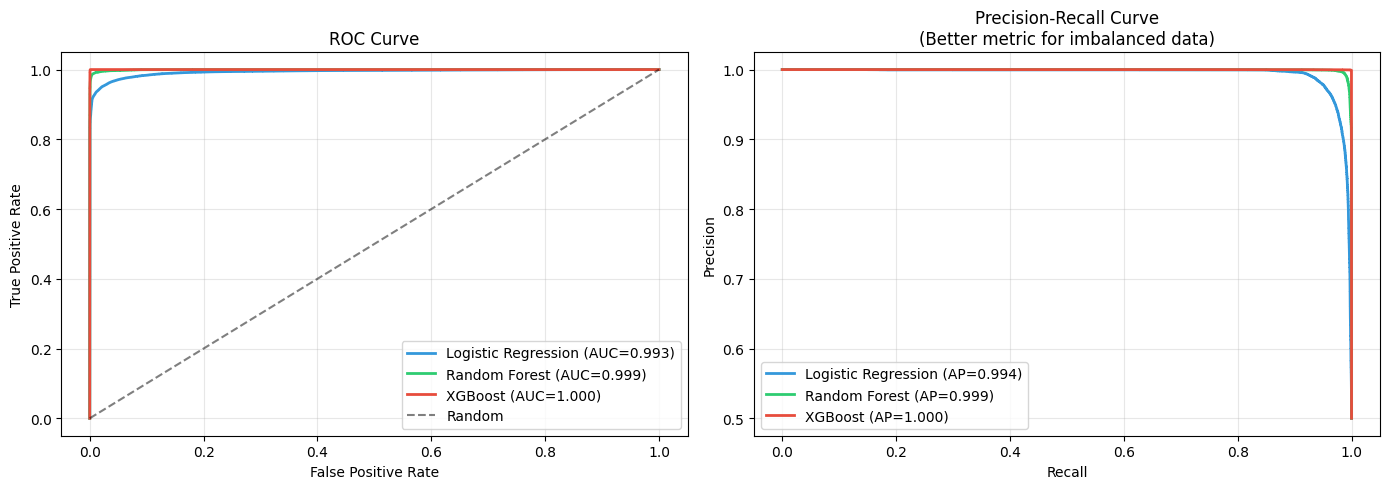

In [56]:
# ── ROC Curve comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (model, name), color in zip(
    [(lr,'Logistic Regression'), (rf,'Random Forest'), (xgb,'XGBoost')],
    colors
):
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=color, lw=2)

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})',
                 color=color, lw=2)

axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\n(Better metric for imbalanced data)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

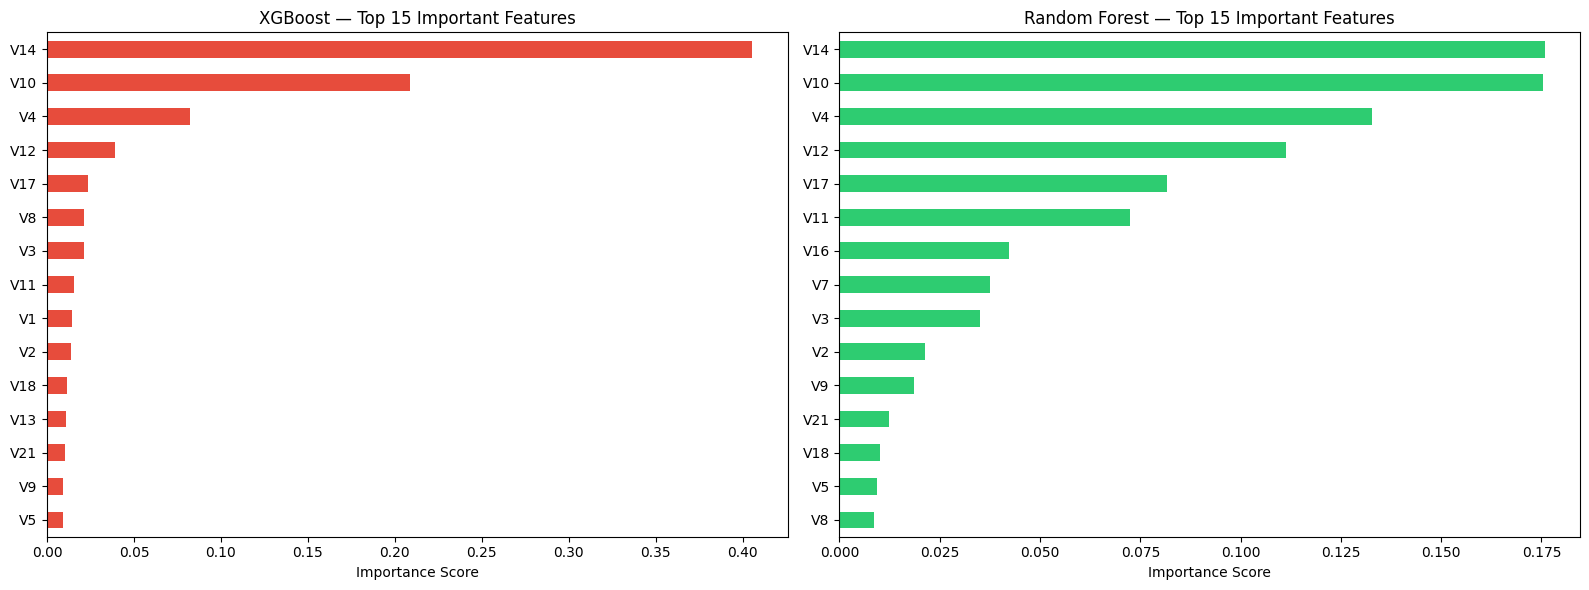

In [57]:
# ── Feature importance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost importance
xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_imp.sort_values().tail(15).plot(
    kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('XGBoost — Top 15 Important Features')
axes[0].set_xlabel('Importance Score')

# Random Forest importance
rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
rf_imp.sort_values().tail(15).plot(
    kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Random Forest — Top 15 Important Features')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters Found:
  subsample: 0.9
  n_estimators: 300
  min_child_weight: 5
  max_depth: 6
  learning_rate: 0.2
  colsample_bytree: 0.8

Best CV Score (AP): 1.0000

  XGBoost (Tuned)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC:           1.0000
Avg Precision(AP): 1.0000


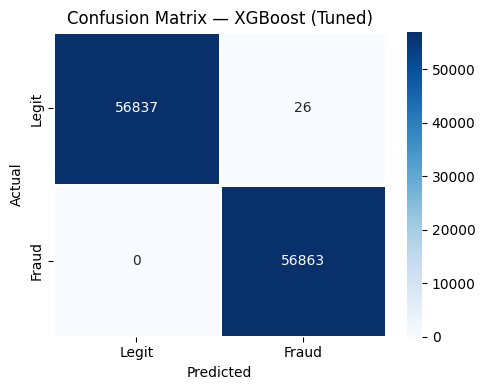

In [59]:
# ── Hyperparameter tuning for best model (XGBoost) ────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5],
}

tuned_xgb = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

tuned_xgb.fit(X_train_sm, y_train_sm)

print("\nBest Parameters Found:")
for k, v in tuned_xgb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV Score (AP): {tuned_xgb.best_score_:.4f}")

best_model = tuned_xgb.best_estimator_
tuned_results = evaluate_model(best_model, X_test, y_test, "XGBoost (Tuned)")


Threshold Analysis:
 Threshold  Precision  Recall     F1  FP Count  FN Count
      0.10     0.9987     1.0 0.9994        73         0
      0.15     0.9991     1.0 0.9996        51         0
      0.20     0.9992     1.0 0.9996        45         0
      0.25     0.9993     1.0 0.9996        42         0
      0.30     0.9993     1.0 0.9997        39         0
      0.35     0.9993     1.0 0.9997        37         0
      0.40     0.9994     1.0 0.9997        32         0
      0.45     0.9995     1.0 0.9998        28         0
      0.50     0.9995     1.0 0.9998        26         0
      0.55     0.9996     1.0 0.9998        25         0
      0.60     0.9996     1.0 0.9998        24         0
      0.65     0.9997     1.0 0.9998        19         0
      0.70     0.9997     1.0 0.9999        16         0
      0.75     0.9997     1.0 0.9999        15         0
      0.80     0.9998     1.0 0.9999        13         0
      0.85     0.9998     1.0 0.9999        13         0


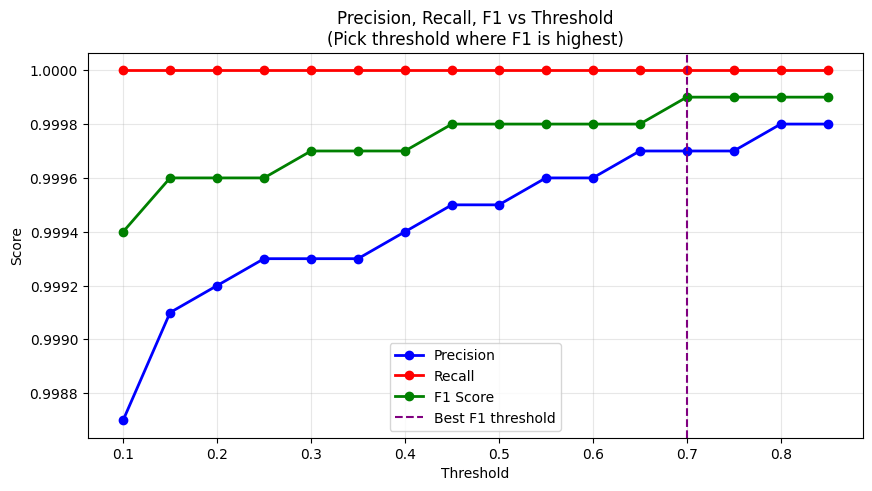


Best threshold (highest F1): 0.7


In [60]:
# ── Threshold Tuning ──────────────────────────────────────
# Lower threshold = catch more fraud BUT more false alarms
# Higher threshold = fewer false alarms BUT miss more fraud

y_proba_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    y_t = (y_proba_best >= t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, y_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_t, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_t, zero_division=0), 4),
        'FP Count':  int(((y_t==1)&(y_test==0)).sum()),
        'FN Count':  int(((y_t==0)&(y_test==1)).sum()),
    })

thresh_df = pd.DataFrame(rows)
print("\nThreshold Analysis:")
print(thresh_df.to_string(index=False))

# Plot threshold vs metrics
plt.figure(figsize=(10, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', lw=2)
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],    'r-o', label='Recall',    lw=2)
plt.plot(thresh_df['Threshold'], thresh_df['F1'],        'g-o', label='F1 Score',  lw=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold\n(Pick threshold where F1 is highest)')
plt.legend()
plt.grid(alpha=0.3)
plt.axvline(x=thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold'],
            color='purple', linestyle='--', label='Best F1 threshold')
plt.legend()
plt.show()

# Best threshold
BEST_THRESHOLD = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f"\nBest threshold (highest F1): {BEST_THRESHOLD}")


FINAL RESULTS (threshold = 0.7)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



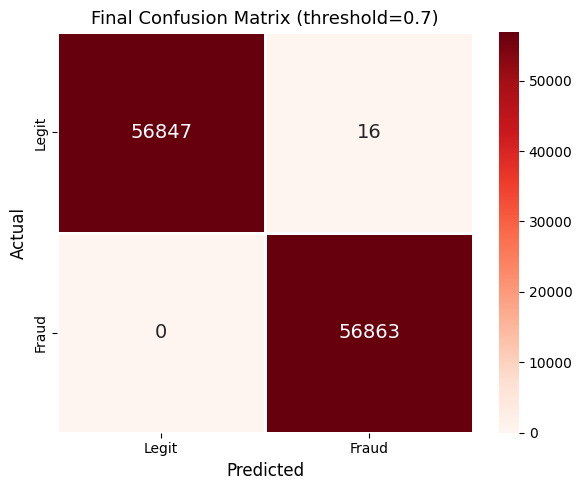


Breakdown:
  Fraud correctly caught (TP): 56,863 / 56,863 (100.0%)
  Fraud missed       (FN):     0
  Legit flagged wrong (FP):    16
  Legit correct       (TN):    56,847


In [61]:
# ── Final evaluation with best threshold ─────────────────
y_final = (y_proba_best >= BEST_THRESHOLD).astype(int)

print(f"\nFINAL RESULTS (threshold = {BEST_THRESHOLD})")
print("="*55)
print(classification_report(y_test, y_final,
      target_names=['Legitimate','Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'],
            linewidths=1, annot_kws={'size':14})
plt.title(f'Final Confusion Matrix (threshold={BEST_THRESHOLD})', fontsize=13)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
total_fraud = tp + fn
print(f"\nBreakdown:")
print(f"  Fraud correctly caught (TP): {tp:,} / {total_fraud:,} ({tp/max(total_fraud,1)*100:.1f}%)")
print(f"  Fraud missed       (FN):     {fn:,}")
print(f"  Legit flagged wrong (FP):    {fp:,}")
print(f"  Legit correct       (TN):    {tn:,}")

In [62]:
# ── Save everything ───────────────────────────────────────
with open('fraud_model.pkl',   'wb') as f: pickle.dump(best_model,      f)
with open('fraud_scaler.pkl',  'wb') as f: pickle.dump(scaler,          f)
with open('fraud_threshold.pkl','wb') as f: pickle.dump(BEST_THRESHOLD, f)
with open('fraud_features.pkl','wb') as f: pickle.dump(X.columns.tolist(), f)

print("Saved: fraud_model.pkl, fraud_scaler.pkl, fraud_threshold.pkl, fraud_features.pkl")

Saved: fraud_model.pkl, fraud_scaler.pkl, fraud_threshold.pkl, fraud_features.pkl


In [63]:
# ── Predict on new transactions ───────────────────────────
# This is how you use the model on any new row from your CSV

def predict_transaction(raw_row_dict, model, scaler, threshold, feature_cols):
    """
    raw_row_dict: dict with keys V1-V28 and Amount
    Example:
        predict_transaction({'V1': -0.26, 'V2': -0.47, ..., 'Amount': 150.0}, ...)
    """
    row = pd.DataFrame([raw_row_dict])

    # Scale amount same way as training
    row['Amount_scaled'] = scaler.transform(row[['Amount']])
    row.drop(columns=['Amount'], inplace=True)

    # Reorder columns to match training
    row = row[feature_cols]

    proba  = model.predict_proba(row)[0][1]
    result = "FRAUD" if proba >= threshold else "LEGITIMATE"

    print(f"Fraud Probability: {proba*100:.2f}%")
    print(f"Prediction:        {result}")
    print(f"Threshold used:    {threshold}")
    return result, proba

# Example — test with row 0 from your dataset
sample_row = {
    'V1':  -0.2606, 'V2': -0.4696, 'V3': 2.4963,  'V4': -0.0837,
    'V5':   0.1297, 'V6':  0.7329, 'V7': 0.5190,  'V8': -0.1300,
    'V9':   0.7272, 'V10': 0.6377, 'V11':-0.9870, 'V12':  0.2934,
    'V13': -0.9414, 'V14': 0.5490, 'V15': 1.8049, 'V16':  0.2156,
    'V17':  0.5123, 'V18': 0.3336, 'V19': 0.1243, 'V20':  0.0912,
    'V21': -0.1106, 'V22': 0.2176, 'V23':-0.1348, 'V24':  0.1660,
    'V25':  0.1263, 'V26':-0.4348, 'V27':-0.0812, 'V28': -0.1510,
    'Amount': 17982.1
}

feature_cols = pickle.load(open('fraud_features.pkl', 'rb'))
predict_transaction(sample_row, best_model, scaler, BEST_THRESHOLD, feature_cols)

Fraud Probability: 0.05%
Prediction:        LEGITIMATE
Threshold used:    0.7


('LEGITIMATE', np.float32(0.00054455287))